# Applicant Behavior Analysis

## Objective

The objective of this project is to analyze applicant behavior throughout the internship application process. The project identifies user navigation patterns, application completion rates, and drop-off points to help improve the overall user experience and increase conversion rates.

In [1]:
# ============================================
# Import Required Libraries
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


## Generate Applicant Behavior Dataset

A synthetic dataset is generated to simulate applicant interactions with the internship platform.

In [2]:
# ============================================
# Generate Applicant Behavior Dataset
# ============================================

import random

np.random.seed(42)
random.seed(42)

n = 1000

traffic_source = [
    "Google",
    "LinkedIn",
    "Facebook",
    "Instagram",
    "Direct"
]

device = [
    "Desktop",
    "Mobile",
    "Tablet"
]

exit_page = [
    "Home",
    "Internship List",
    "Application Form",
    "Resume Upload",
    "Confirmation"
]

df = pd.DataFrame({

    "Applicant_ID":[f"APP{1001+i}" for i in range(n)],

    "Traffic_Source":np.random.choice(traffic_source,n),

    "Device":np.random.choice(device,n,p=[0.45,0.45,0.10]),

    "Pages_Visited":np.random.randint(1,10,n),

    "Time_Spent_Minutes":np.random.randint(1,31,n),

    "Application_Completed":np.random.choice(
        ["Yes","No"],
        n,
        p=[0.7,0.3]
    ),

    "Exit_Page":np.random.choice(exit_page,n)

})

df.to_csv(
    "Applicant_Behavior.csv",
    index=False
)

print("Dataset Generated Successfully!")

print(df.shape)

display(df.head())

Dataset Generated Successfully!
(1000, 7)


,Applicant_ID,Traffic_Source,Device,Pages_Visited,Time_Spent_Minutes,Application_Completed,Exit_Page
0,APP1001,Instagram,Tablet,1,1,Yes,Application Form
1,APP1002,Direct,Mobile,3,4,Yes,Confirmation
2,APP1003,Facebook,Mobile,8,13,No,Application Form
3,APP1004,Direct,Tablet,3,23,No,Resume Upload
4,APP1005,Direct,Mobile,8,13,Yes,Resume Upload


## Dataset Overview

The generated dataset is explored to understand its structure, dimensions, data types, and overall quality before performing behavior analysis.

In [3]:
# ============================================
# Dataset Overview
# ============================================

print("First 5 Records")
display(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nColumn Names")
print(df.columns.tolist())

print("\nData Types")
display(df.dtypes)

print("\nDataset Information")
df.info()

First 5 Records


,Applicant_ID,Traffic_Source,Device,Pages_Visited,Time_Spent_Minutes,Application_Completed,Exit_Page
0,APP1001,Instagram,Tablet,1,1,Yes,Application Form
1,APP1002,Direct,Mobile,3,4,Yes,Confirmation
2,APP1003,Facebook,Mobile,8,13,No,Application Form
3,APP1004,Direct,Tablet,3,23,No,Resume Upload
4,APP1005,Direct,Mobile,8,13,Yes,Resume Upload



Dataset Shape
(1000, 7)

Column Names
['Applicant_ID', 'Traffic_Source', 'Device', 'Pages_Visited', 'Time_Spent_Minutes', 'Application_Completed', 'Exit_Page']

Data Types


Applicant_ID             object
Traffic_Source           object
Device                   object
Pages_Visited             int32
Time_Spent_Minutes        int32
Application_Completed    object
Exit_Page                object
dtype: object


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Applicant_ID           1000 non-null   object
 1   Traffic_Source         1000 non-null   object
 2   Device                 1000 non-null   object
 3   Pages_Visited          1000 non-null   int32 
 4   Time_Spent_Minutes     1000 non-null   int32 
 5   Application_Completed  1000 non-null   object
 6   Exit_Page              1000 non-null   object
dtypes: int32(2), object(5)
memory usage: 47.0+ KB


## Descriptive Statistics

Summary statistics are generated to understand applicant behavior, including pages visited and time spent on the platform.

In [4]:
# ============================================
# Descriptive Statistics
# ============================================

display(df.describe())

,Pages_Visited,Time_Spent_Minutes
count,1000.00000,1000.000000
mean,5.00700,15.689000
std,2.57674,8.739832
min,1.00000,1.000000
25%,3.00000,8.000000
50%,5.00000,16.000000
75%,7.00000,23.000000
max,9.00000,30.000000


##  Conversion Rate Analysis

This step calculates the percentage of applicants who successfully completed the internship application process.

In [5]:
# ============================================
# Conversion Rate
# ============================================

conversion = df["Application_Completed"].value_counts()

conversion_rate = round(
    conversion["Yes"] / len(df) * 100,
    2
)

drop_rate = round(
    conversion["No"] / len(df) * 100,
    2
)

print(f"Application Completion Rate : {conversion_rate}%")
print(f"Drop-off Rate : {drop_rate}%")

display(conversion)

Application Completion Rate : 72.0%
Drop-off Rate : 28.0%


Application_Completed
Yes    720
No     280
Name: count, dtype: int64

## Exit Page Analysis

This analysis identifies the pages where applicants most frequently leave the application process.

In [6]:
# ============================================
# Exit Page Analysis
# ============================================

exit_summary = df["Exit_Page"].value_counts()

display(exit_summary)

Exit_Page
Internship List     211
Home                207
Application Form    199
Confirmation        192
Resume Upload       191
Name: count, dtype: int64

### Observation

The exit page analysis helps identify bottlenecks in the application journey. Pages with a high number of exits may require usability improvements to increase application completion rates.

##  Application Completion Status

This chart compares the number of applicants who completed the application process versus those who dropped off.

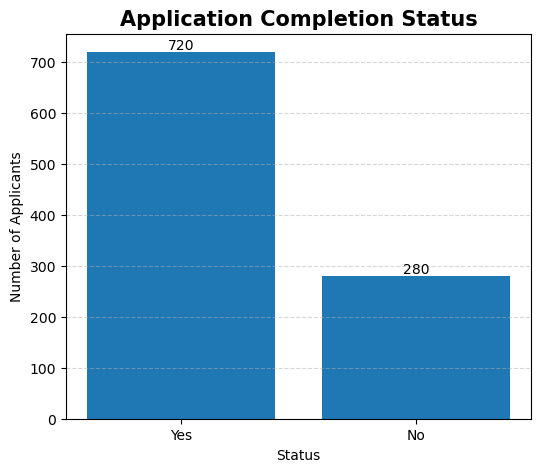

In [8]:
# ============================================
# Graph 1: Application Completion
# ============================================

completion = df["Application_Completed"].value_counts()

plt.figure(figsize=(6,5))

bars = plt.bar(
    completion.index,
    completion.values
)

plt.title("Application Completion Status", fontsize=15, fontweight="bold")
plt.xlabel("Status")
plt.ylabel("Number of Applicants")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+5,
        int(bar.get_height()),
        ha="center"
    )

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

##  Application Completion Percentage

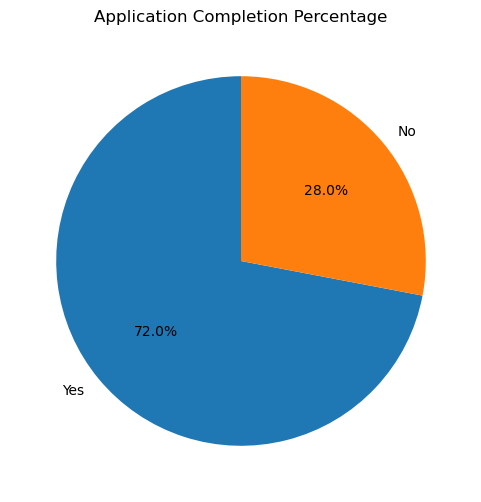

In [9]:
# ============================================
# Graph 2: Completion Percentage
# ============================================

plt.figure(figsize=(6,6))

plt.pie(
    completion.values,
    labels=completion.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Application Completion Percentage")

plt.show()

##  Traffic Source Analysis

This chart shows which traffic sources bring the highest number of applicants.

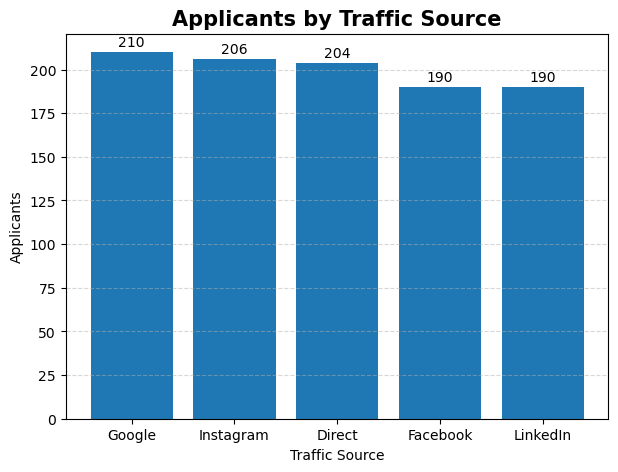

In [10]:
# ============================================
# Graph 3: Traffic Source
# ============================================

traffic = df["Traffic_Source"].value_counts()

plt.figure(figsize=(7,5))

bars = plt.bar(
    traffic.index,
    traffic.values
)

plt.title("Applicants by Traffic Source", fontsize=15, fontweight="bold")
plt.xlabel("Traffic Source")
plt.ylabel("Applicants")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+3,
        int(bar.get_height()),
        ha="center"
    )

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

##  Device-wise Applicant Distribution

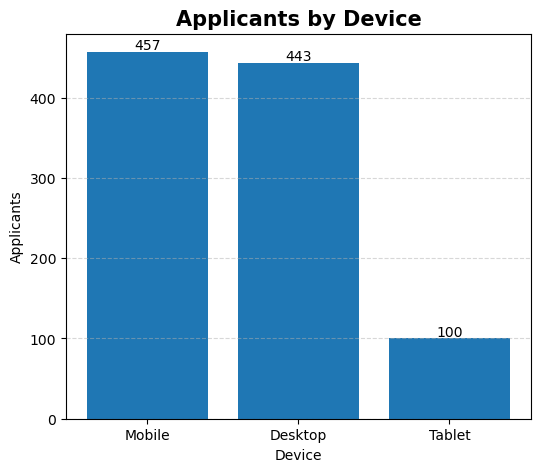

In [11]:
# ============================================
# Graph 4: Device Distribution
# ============================================

device = df["Device"].value_counts()

plt.figure(figsize=(6,5))

bars = plt.bar(
    device.index,
    device.values
)

plt.title("Applicants by Device", fontsize=15, fontweight="bold")
plt.xlabel("Device")
plt.ylabel("Applicants")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+3,
        int(bar.get_height()),
        ha="center"
    )

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

##  Exit Page Distribution

This chart highlights the pages where applicants most frequently leave the application process.

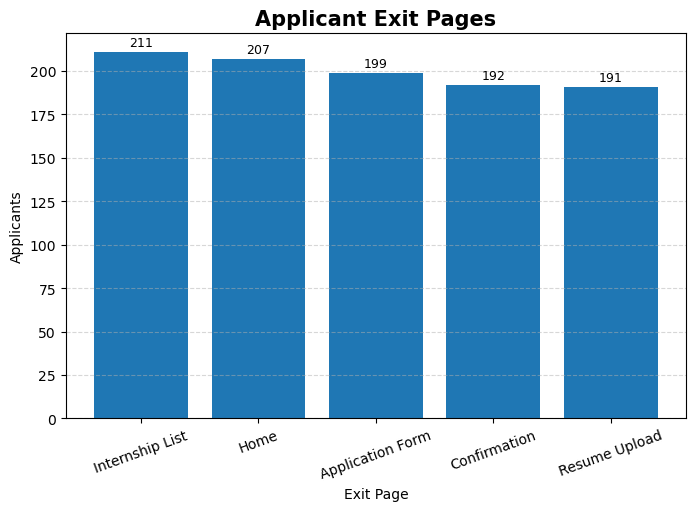

In [12]:
# ============================================
# Graph 5: Exit Page
# ============================================

exit_page = df["Exit_Page"].value_counts()

plt.figure(figsize=(8,5))

bars = plt.bar(
    exit_page.index,
    exit_page.values
)

plt.title("Applicant Exit Pages", fontsize=15, fontweight="bold")
plt.xlabel("Exit Page")
plt.ylabel("Applicants")

plt.xticks(rotation=20)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+3,
        int(bar.get_height()),
        ha="center",
        fontsize=9
    )

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

##  Pages Visited Distribution

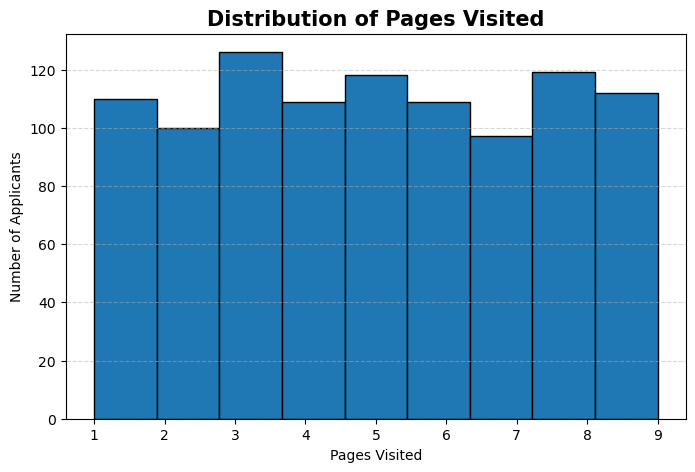

In [13]:
# ============================================
# Graph 6: Pages Visited
# ============================================

plt.figure(figsize=(8,5))

plt.hist(
    df["Pages_Visited"],
    bins=9,
    edgecolor="black"
)

plt.title("Distribution of Pages Visited", fontsize=15, fontweight="bold")
plt.xlabel("Pages Visited")
plt.ylabel("Number of Applicants")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

##  Applicant Behavior Summary Report

This report summarizes key applicant behavior metrics, including application completion, average pages visited, and average time spent on the platform.

In [14]:
# ============================================
# Applicant Behavior Summary Report
# ============================================

summary = pd.DataFrame({

    "Metric":[
        "Total Applicants",
        "Application Completion Rate (%)",
        "Drop-off Rate (%)",
        "Average Pages Visited",
        "Average Time Spent (Minutes)"
    ],

    "Value":[

        len(df),

        round((df["Application_Completed"]=="Yes").mean()*100,2),

        round((df["Application_Completed"]=="No").mean()*100,2),

        round(df["Pages_Visited"].mean(),2),

        round(df["Time_Spent_Minutes"].mean(),2)

    ]

})

display(summary)

,Metric,Value
0,Total Applicants,1000.00
1,Application Completion Rate (%),72.00
2,Drop-off Rate (%),28.00
3,Average Pages Visited,5.01
4,Average Time Spent (Minutes),15.69


##  Traffic Source Summary

This table summarizes applicant traffic sources and their contribution to total visits.

In [15]:
# ============================================
# Traffic Source Summary
# ============================================

traffic_summary = pd.DataFrame({

    "Applicants":df["Traffic_Source"].value_counts(),

    "Percentage (%)":round(
        df["Traffic_Source"].value_counts(normalize=True)*100,
        2
    )

})

display(traffic_summary)

,Applicants,Percentage (%)
Traffic_Source,,
Google,210,21.0
Instagram,206,20.6
Direct,204,20.4
Facebook,190,19.0
LinkedIn,190,19.0


# Business Recommendations

Based on the applicant behavior analysis, the following recommendations are suggested:

1. Optimize pages with the highest exit rates.
2. Simplify the application form to reduce drop-offs.
3. Improve the mobile experience for applicants.
4. Invest more in high-performing traffic sources.
5. Reduce the number of steps required to complete an application.
6. Continuously monitor applicant behavior to improve conversion rates.

# Conclusion

This project analyzed applicant behavior using a simulated internship platform dataset. Key metrics such as application completion rate, traffic sources, page visits, time spent, and exit pages were evaluated to identify user behavior patterns and bottlenecks. The insights can help improve user experience and increase application conversion rates.

##  Save Final Dataset

In [16]:
# ============================================
# Save Final Dataset
# ============================================

df.to_csv(
    "Applicant_Behavior_Analysis.csv",
    index=False
)

print("Final Dataset Saved Successfully!")

print(df.shape)

Final Dataset Saved Successfully!
(1000, 7)


# References

- Python Documentation
- Pandas Documentation
- NumPy Documentation
- Matplotlib Documentation